# Pricing of a Bermudan Basket Option — Numerical Finance Project
**Author:** Mohamed Abdellahi  
**Lecturer:** Kaiza AMOUH  
**Deadline:** May 3rd, 2026

---

This notebook implements the pricing of a **Bermudan Basket Option** using Monte Carlo simulation, progressively combining several variance reduction methods.

## Question 1(a) — European Basket Call: Basic Monte Carlo

We price the following option:

$$\text{Payoff} = \left( \sum_{i=1}^n \alpha_i S_i^T - K \right)^+$$

**Method:** Pure Monte Carlo using pseudo-random numbers (L'Ecuyer Combined generator), with no variance reduction.

**Diffusion:** Correlated multi-dimensional Black-Scholes, Euler-Maruyama scheme:

$$dS_i = r \, S_i \, dt + \sigma_i \, S_i \, dW_i, \quad d\langle W_i, W_j \rangle = \rho_{ij} \, dt$$

Correlated Gaussian vectors are simulated via the Cholesky decomposition of the correlation matrix $\Sigma = L L^T$.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from random_generator.ecuyer_combined import EcuyerCombined
from random_generator.normal import NormalBoxMuller
from sde.bs_euler_nd import BSEulerND
from payoff.basket_payoff import BasketCallPayoff
from pricer.mc_engine import MCEngine
from pricer.basic_mapping import BasicMapping

In [3]:
# ============================================================
# Model Parameters
# ============================================================

n        = 3                        # number of assets
spots    = [100.0, 100.0, 100.0]    # initial spot prices S_i(0)
rates    = [0.05,  0.05,  0.05]     # risk-free rates (same for all assets)
vols     = [0.20,  0.25,  0.30]     # volatilities σ_i
weights  = [1/3,   1/3,   1/3]      # basket weights αi (equal, sum = 1)
K        = 100.0                    # strike price
T        = 1.0                      # maturity (years)
nb_steps = 252                      # discretization steps (1 per trading day)
nb_paths = 50_000                   # number of Monte Carlo paths

# n x n correlation matrix
correlation_matrix = [
    [1.0,  0.5,  0.3],
    [0.5,  1.0,  0.4],
    [0.3,  0.4,  1.0],
]

print("Model Parameters:")
print(f"  Assets            : {n}")
print(f"  Spot prices       : {spots}")
print(f"  Risk-free rate r  : {rates[0]}")
print(f"  Volatilities      : {vols}")
print(f"  Weights αi        : {weights}")
print(f"  Strike K          : {K}")
print(f"  Maturity T        : {T}")
print(f"  Time steps        : {nb_steps}")
print(f"  MC paths          : {nb_paths:,}")
print(f"\n  Correlation matrix:")
for row in correlation_matrix:
    print("   ", row)

Model Parameters:
  Assets            : 3
  Spot prices       : [100.0, 100.0, 100.0]
  Risk-free rate r  : 0.05
  Volatilities      : [0.2, 0.25, 0.3]
  Weights αi        : [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
  Strike K          : 100.0
  Maturity T        : 1.0
  Time steps        : 252
  MC paths          : 50,000

  Correlation matrix:
    [1.0, 0.5, 0.3]
    [0.5, 1.0, 0.4]
    [0.3, 0.4, 1.0]


In [4]:
# ============================================================
# Monte Carlo Simulation — Pure Pseudo-Random (L'Ecuyer + Box-Muller)
# ============================================================

# Pseudo-random generator: L'Ecuyer Combined (better quality than simple LCG)
uniform_gen = EcuyerCombined(seed1=12345, seed2=67890)
normal_gen  = NormalBoxMuller(mu=0, sigma=1, uniform=uniform_gen)

# Process: BSEulerND — n correlated assets
process = BSEulerND(
    generator          = normal_gen,
    spots              = spots,
    rates              = rates,
    vols               = vols,
    correlation_matrix = correlation_matrix,
)

# Payoff: Basket Call — max(Σ αi·Si_T - K, 0)
payoff = BasketCallPayoff(weights=weights, strike=K)

# Run simulation
engine  = MCEngine()
mapping = BasicMapping(payoff, process)
result  = engine.price(mapping, nb_paths=nb_paths, T=T, nb_steps=nb_steps, rate=rates[0])

print("=" * 55)
print("Question 1(a) — Basic MC (pseudo-random numbers)")
print("=" * 55)
print(f"  Estimated price   : {result.price:.4f}")
print(f"  Standard error    : {result.std_error:.4f}")
print(f"  95% CI            : [{result.conf_interval[0]:.4f}, {result.conf_interval[1]:.4f}]")
print(f"  CI width          : {result.conf_interval[1] - result.conf_interval[0]:.4f}")
print(f"  Paths used        : {result.nb_paths:,}")
print(f"  Method            : {result.method}")

Question 1(a) — Basic MC (pseudo-random numbers)
  Estimated price   : 10.2840
  Standard error    : 0.0644
  95% CI            : [10.1578, 10.4103]
  CI width          : 0.2526
  Paths used        : 50,000
  Method            : BasicMapping


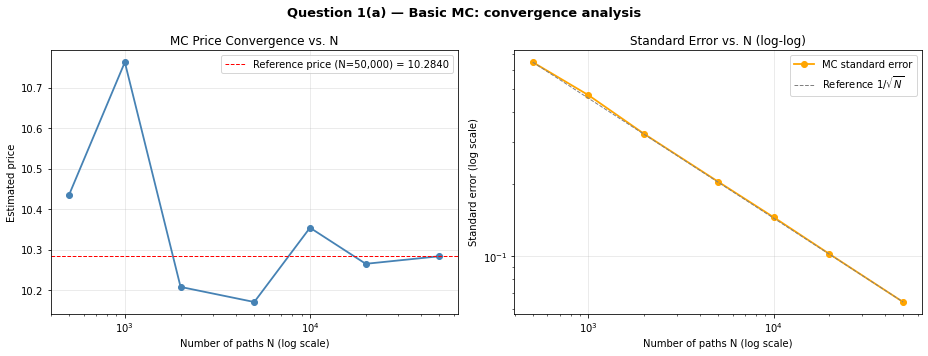


Convergence Table:
       N |    Price |  Std Err |   95% CI width
------------------------------------------------
     500 |  10.4358 |   0.6445 |         2.5264
   1,000 |  10.7633 |   0.4695 |         1.8404
   2,000 |  10.2083 |   0.3236 |         1.2685
   5,000 |  10.1711 |   0.2049 |         0.8032
  10,000 |  10.3545 |   0.1454 |         0.5700
  20,000 |  10.2654 |   0.1022 |         0.4008
  50,000 |  10.2840 |   0.0644 |         0.2526


In [5]:
# ============================================================
# Price Convergence as a Function of Number of Paths
# ============================================================

path_counts = [500, 1_000, 2_000, 5_000, 10_000, 20_000, 50_000]
prices_mc   = []
stderrs_mc  = []

for N in path_counts:
    u    = EcuyerCombined(seed1=12345, seed2=67890)
    ng   = NormalBoxMuller(mu=0, sigma=1, uniform=u)
    proc = BSEulerND(generator=ng, spots=spots, rates=rates,
                     vols=vols, correlation_matrix=correlation_matrix)
    res  = engine.price(BasicMapping(payoff, proc), nb_paths=N, T=T,
                        nb_steps=nb_steps, rate=rates[0])
    prices_mc.append(res.price)
    stderrs_mc.append(res.std_error)

prices_mc  = np.array(prices_mc)
stderrs_mc = np.array(stderrs_mc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: price convergence ---
axes[0].plot(path_counts, prices_mc, 'o-', color='steelblue', linewidth=1.8)
axes[0].axhline(result.price, color='red', linestyle='--', linewidth=1,
                label=f"Reference price (N={nb_paths:,}) = {result.price:.4f}")
axes[0].set_xscale('log')
axes[0].set_title("MC Price Convergence vs. N")
axes[0].set_xlabel("Number of paths N (log scale)")
axes[0].set_ylabel("Estimated price")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: standard error (should decay as 1/√N) ---
ns = np.array(path_counts, dtype=float)
axes[1].plot(path_counts, stderrs_mc, 'o-', color='orange', linewidth=1.8, label="MC standard error")
axes[1].plot(path_counts, stderrs_mc[0] * np.sqrt(path_counts[0] / ns),
             '--', color='grey', linewidth=1, label=r"Reference $1/\sqrt{N}$")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title(r"Standard Error vs. N (log-log)")
axes[1].set_xlabel("Number of paths N (log scale)")
axes[1].set_ylabel("Standard error (log scale)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Question 1(a) — Basic MC: convergence analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConvergence Table:")
print(f"{'N':>8} | {'Price':>8} | {'Std Err':>8} | {'95% CI width':>14}")
print("-" * 48)
for i, N in enumerate(path_counts):
    width = 2 * 1.96 * stderrs_mc[i]
    print(f"{N:>8,} | {prices_mc[i]:>8.4f} | {stderrs_mc[i]:>8.4f} | {width:>14.4f}")

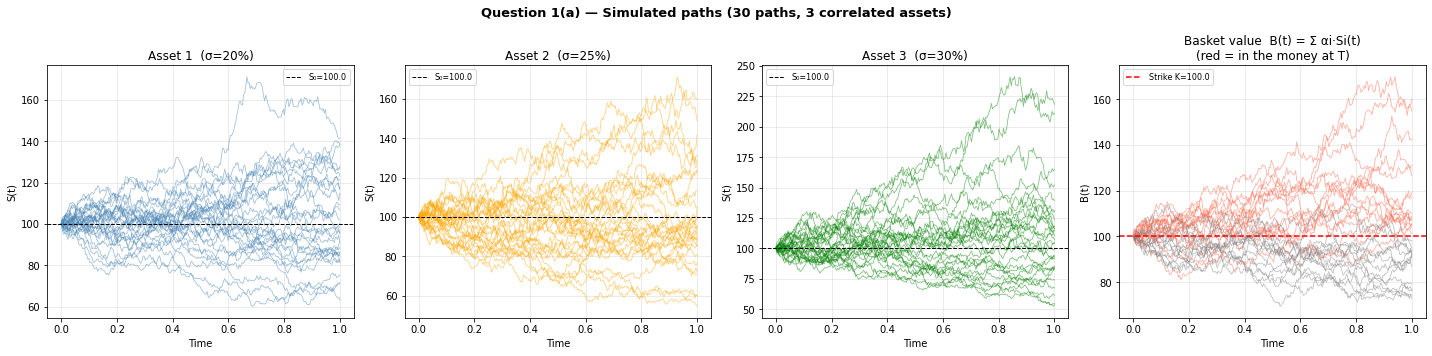

In [6]:
# ============================================================
# Visualisation of Simulated Asset Paths and Basket
# ============================================================

NB_VIS   = 30   # number of paths to display
time_grid = np.linspace(0, T, nb_steps + 1)

# Simulate paths for visualisation
u_vis    = EcuyerCombined(seed1=11111, seed2=22222)
ng_vis   = NormalBoxMuller(mu=0, sigma=1, uniform=u_vis)
proc_vis = BSEulerND(generator=ng_vis, spots=spots, rates=rates,
                     vols=vols, correlation_matrix=correlation_matrix)

all_paths = engine.simulate_paths(proc_vis, nb_paths=NB_VIS, T=T, nb_steps=nb_steps)
# all_paths[i][dim] = List[float] — full path for simulation i, asset dim

# --- Compute basket value B(t) = Σ αi·Si(t) for each path ---
basket_paths = []
for i in range(NB_VIS):
    basket = [
        sum(weights[d] * all_paths[i][d][step] for d in range(n))
        for step in range(nb_steps + 1)
    ]
    basket_paths.append(basket)

fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 5))

colors = ['steelblue', 'orange', 'green']

# --- One subplot per asset ---
for d in range(n):
    for i in range(NB_VIS):
        axes[d].plot(time_grid, all_paths[i][d], alpha=0.5, linewidth=0.8, color=colors[d])
    axes[d].axhline(spots[d], color='k', linestyle='--', linewidth=1, label=f"S₀={spots[d]}")
    axes[d].set_title(f"Asset {d+1}  (σ={vols[d]:.0%})")
    axes[d].set_xlabel("Time")
    axes[d].set_ylabel("S(t)")
    axes[d].legend(fontsize=8)
    axes[d].grid(alpha=0.3)

# --- Last subplot: basket value B(t) = Σ αi·Si(t) ---
for i in range(NB_VIS):
    color = 'tomato' if basket_paths[i][-1] > K else 'grey'
    axes[n].plot(time_grid, basket_paths[i], alpha=0.5, linewidth=0.8, color=color)
axes[n].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f"Strike K={K}")
axes[n].set_title("Basket value  B(t) = Σ αi·Si(t)\n(red = in the money at T)")
axes[n].set_xlabel("Time")
axes[n].set_ylabel("B(t)")
axes[n].legend(fontsize=8)
axes[n].grid(alpha=0.3)

plt.suptitle(f"Question 1(a) — Simulated paths ({NB_VIS} paths, {n} correlated assets)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Question 1(b) — Variance Reduction Techniques

We compare three methods to reduce the Monte Carlo estimation error for a fixed simulation budget $N$.

### 1. Quasi-Random Numbers (QMC — Sobol)

Replace the pseudo-random generator with a **Sobol low-discrepancy sequence**.  
Sobol sequences fill the unit hypercube more uniformly than pseudo-random numbers.  
The theoretical convergence rate improves from $O(N^{-1/2})$ toward $O\!\left((\log N)^d / N\right)$.

> Best practice: use $N$ equal to a power of 2 to exploit the equidistribution properties of Sobol sequences.

### 2. Antithetic Variables

For each Gaussian draw $Z$, also simulate the **mirror path** $-Z$.  
The antithetic estimator is:
$$\hat{V}_{AV} = e^{-rT} \frac{1}{N} \sum_{j=1}^{N} \frac{f(S^j_Z) + f(S^j_{-Z})}{2}$$
The variance reduction factor is $1 + \text{Corr}(f(Z), f(-Z))$, which is $< 1$ for monotone payoffs such as a call.

### 3. Control Variate (Geometric Basket)

The **geometric basket call** has a closed-form Black-Scholes-like price (since $\log G_T$ is Gaussian).  
We use it as a control variate $g$ correlated with the arithmetic basket payoff $f$:
$$\hat{V}_{CV} = e^{-rT} \frac{1}{N} \sum_{j=1}^{N} \left[ f(S^j) - \hat\beta \left(g(S^j) - \mathbb{E}[g]\right) \right]$$
with optimal coefficient $\hat\beta = \widehat{\text{Cov}}(f,g) \,/\, \widehat{\text{Var}}(g)$ estimated on a pilot sample.

In [ ]:
# ============================================================
# Q1(b)(i) — Quasi-Random Numbers: Randomized QMC (rQMC)
# ============================================================
# Box-Muller MUST NOT be used with quasi-random sequences:
#   it pairs consecutive values (u1, u2) and transforms them jointly,
#   which destroys the low-discrepancy structure of Sobol.
#
# The correct approach is the INVERSE CDF transform: Z = Φ⁻¹(u)
#   - One-to-one mapping: each u_i → Z_i independently
#   - Preserves the low-discrepancy property in the normal domain
#   - Standard recommendation in QMC literature (L'Ecuyer, Lemieux)
#
# Error estimation uses RANDOMIZED QMC (rQMC):
#   R independent scramblings → R unbiased estimates → std dev / sqrt(R).
import math as _math
from scipy.stats import norm as _scipy_norm
from random_generator import SobolGenerator
from random_generator.normal import NormalBoxMuller as _NBM_base

class _NormalInverseCDF(_NBM_base):
    """
    N(0,1) via inverse CDF: Z = Φ⁻¹(u).
    Subclasses NormalBoxMuller so RandomProcess accepts it as a RandomGenerator.
    Overrides generate() to use the inverse CDF instead of Box-Muller.
    Safe for quasi-random sequences (no pairing of consecutive values).
    """
    def generate(self) -> float:
        u = self._uniform.generate()
        u = max(1e-10, min(1 - 1e-10, u))   # guard against ±inf
        return float(_scipy_norm.ppf(u))

R             = 10     # independent scramblings
NB_PATHS_QMC  = 4096   # 2^12 — power of 2 for optimal Sobol equidistribution
nb_steps_qmc  = 50     # fewer steps than baseline: faster, same variance comparison

rqmc_prices = []
for r in range(R):
    u_r    = SobolGenerator(dimension=1, scramble=True, seed=r)
    ng_r   = _NormalInverseCDF(mu=0, sigma=1, uniform=u_r)   # ← inverse CDF
    proc_r = BSEulerND(ng_r, spots, rates, vols, correlation_matrix)
    map_r  = BasicMapping(payoff, proc_r)
    res_r  = engine.price(map_r, nb_paths=NB_PATHS_QMC, T=T, nb_steps=nb_steps_qmc, rate=rates[0])
    rqmc_prices.append(res_r.price)

# rQMC error: sample std dev across R replication means / sqrt(R)
rqmc_mean      = sum(rqmc_prices) / R
rqmc_var_rep   = sum((p - rqmc_mean) ** 2 for p in rqmc_prices) / (R - 1)
rqmc_std_error = _math.sqrt(rqmc_var_rep / R)
rqmc_ci        = (rqmc_mean - 1.96 * rqmc_std_error,
                  rqmc_mean + 1.96 * rqmc_std_error)
ci_width_qmc   = rqmc_ci[1] - rqmc_ci[0]

# Equal-budget pseudo-random baseline (same total paths, same nb_steps)
NB_PATHS_EQ = R * NB_PATHS_QMC
u_eq    = EcuyerCombined(seed1=12345, seed2=67890)
ng_eq   = NormalBoxMuller(mu=0, sigma=1, uniform=u_eq)
proc_eq = BSEulerND(ng_eq, spots, rates, vols, correlation_matrix)
res_eq  = engine.price(BasicMapping(payoff, proc_eq), nb_paths=NB_PATHS_EQ,
                       T=T, nb_steps=nb_steps_qmc, rate=rates[0])
ci_width_eq   = res_eq.conf_interval[1] - res_eq.conf_interval[0]
vr_factor_qmc = (res_eq.std_error / rqmc_std_error) ** 2 if rqmc_std_error > 0 else float('inf')

print("=== Q1(b)(i) — Randomized QMC (Sobol + inverse CDF) ===")
print(f"  Replications    : {R}  ×  {NB_PATHS_QMC:,} paths  =  {R*NB_PATHS_QMC:,} total")
print(f"  rQMC Price      : {rqmc_mean:.4f}")
print(f"  rQMC Std Error  : {rqmc_std_error:.4f}")
print(f"  95% CI          : [{rqmc_ci[0]:.4f}, {rqmc_ci[1]:.4f}]")
print(f"  CI width        : {ci_width_qmc:.4f}")
print()
print(f"  Pseudo-random (equal budget, N={NB_PATHS_EQ:,}):")
print(f"    Std Error     : {res_eq.std_error:.4f}")
print(f"    CI width      : {ci_width_eq:.4f}")
print(f"  Variance reduction factor vs equal budget: {vr_factor_qmc:.2f}x")

# Store for summary cell
result_qmc    = type('R', (), {'price': rqmc_mean, 'std_error': rqmc_std_error,
                               'conf_interval': rqmc_ci})()



In [11]:
# ============================================================
# Q1(b)(ii) — Antithetic Variables
# ============================================================
# AntitheticMapping requires BSMilsteinND (log-Euler exact scheme).
# Each simulation produces a pair (Z, -Z): f(Z) and f(-Z) are averaged.
from sde import BSMilsteinND
from pricer import AntitheticMapping

u_anti    = EcuyerCombined(12345, 67890)
ng_anti   = NormalBoxMuller(mu=0, sigma=1, uniform=u_anti)
proc_anti = BSMilsteinND(ng_anti, spots, rates, vols, correlation_matrix)
map_anti  = AntitheticMapping(proc_anti, payoff)

result_anti = engine.price(map_anti, nb_paths=nb_paths, T=T, nb_steps=nb_steps, rate=rates[0])

ci_width_anti  = result_anti.conf_interval[1] - result_anti.conf_interval[0]
vr_factor_anti = (result.std_error / result_anti.std_error) ** 2

print("=== Q1(b)(ii) — Antithetic Variables ===")
print(f"  nb_paths        : {nb_paths:,}")
print(f"  Price           : {result_anti.price:.4f}")
print(f"  Std Error       : {result_anti.std_error:.4f}")
print(f"  95% CI          : [{result_anti.conf_interval[0]:.4f}, {result_anti.conf_interval[1]:.4f}]")
print(f"  CI width        : {ci_width_anti:.4f}")
print(f"  Variance reduction factor: {vr_factor_anti:.2f}x")

=== Q1(b)(ii) — Antithetic Variables ===
  nb_paths        : 50,000
  Price           : 10.3082
  Std Error       : 0.0457
  95% CI          : [10.2187, 10.3977]
  CI width        : 0.1790
  Variance reduction factor: 1.99x


In [ ]:
# ============================================================
# Q1(b)(iii) — Control Variate (Geometric Basket)
# ============================================================
# The geometric basket call log(G_T) = sum(w_i * log(S_i_T)) is Gaussian,
# so its option price has a closed-form Black-Scholes-like formula.
# We exploit the strong correlation between arithmetic and geometric payoffs.
import math
from payoff import GeometricBasketPayoff
from pricer import ControlVariateMapping

geo_payoff = GeometricBasketPayoff(weights, K, spots, T, rates[0], vols, correlation_matrix)
price_geo  = geo_payoff.analytical_price()
E_cv       = price_geo * math.exp(rates[0] * T)   # undiscounted expectation E[g(S_T)]

print(f"  Geometric basket call — analytical price : {price_geo:.4f}")
print(f"  E[g] undiscounted (= E_cv)               : {E_cv:.4f}")

u_cv    = EcuyerCombined(99999, 11111)
ng_cv   = NormalBoxMuller(mu=0, sigma=1, uniform=u_cv)
proc_cv = BSEulerND(ng_cv, spots, rates, vols, correlation_matrix)
map_cv  = ControlVariateMapping(proc_cv, payoff, geo_payoff, E_cv,
                                T_pilot=T, nb_steps_pilot=nb_steps,
                                pilot_paths=2000)

print(f"  Estimated optimal beta               : {map_cv.beta:.4f}")
print()

result_cv = engine.price(map_cv, nb_paths=nb_paths, T=T, nb_steps=nb_steps, rate=rates[0])

ci_width_cv  = result_cv.conf_interval[1] - result_cv.conf_interval[0]
vr_factor_cv = (result.std_error / result_cv.std_error) ** 2

print("=== Q1(b)(iii) — Control Variate ===")
print(f"  nb_paths        : {nb_paths:,}")
print(f"  Price           : {result_cv.price:.4f}")
print(f"  Std Error       : {result_cv.std_error:.4f}")
print(f"  95% CI          : [{result_cv.conf_interval[0]:.4f}, {result_cv.conf_interval[1]:.4f}]")
print(f"  CI width        : {ci_width_cv:.4f}")
print(f"  Variance reduction factor: {vr_factor_cv:.2f}x")

In [ ]:
# ============================================================
# Q1(b) — Summary: All Variance Reduction Methods
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

methods     = ["Pseudo-random\n(Baseline)", "rQMC\n(Sobol)", "Antithetic\nVariables", "Control\nVariate"]
prices_all  = [result.price,      result_qmc.price,  result_anti.price,  result_cv.price]
stderrs_all = [result.std_error,  result_qmc.std_error, result_anti.std_error, result_cv.std_error]
ci_widths   = [result.conf_interval[1]       - result.conf_interval[0],
               result_qmc.conf_interval[1]   - result_qmc.conf_interval[0],
               result_anti.conf_interval[1]  - result_anti.conf_interval[0],
               result_cv.conf_interval[1]    - result_cv.conf_interval[0]]
vr_factors  = [1.0, vr_factor_qmc, vr_factor_anti, vr_factor_cv]

# Print summary table
print("=" * 90)
print(f"{'Method':<30} {'Price':>8} {'Std Error':>11} {'95% CI Width':>13} {'VR Factor':>11}")
print("-" * 90)
for m, p, s, w, v in zip(methods, prices_all, stderrs_all, ci_widths, vr_factors):
    vr_str = f"{v:.2f}x" if v != float('inf') else "∞"
    print(f"{m.replace(chr(10),' '):<30} {p:>8.4f} {s:>11.4f} {w:>13.4f} {vr_str:>11}")
print("=" * 90)
print("  Note: rQMC std error is estimated across 20 independent scramblings.")

# Plot comparison
colors_vr = ['#aaaaaa', '#2196F3', '#4CAF50', '#FF9800']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Q1(b) — Variance Reduction Methods Comparison", fontsize=13, fontweight='bold')

# Left: Standard error by method
ax1 = axes[0]
bars1 = ax1.bar(range(len(methods)), stderrs_all, color=colors_vr, edgecolor='black', linewidth=0.8)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, fontsize=9)
ax1.set_ylabel("Standard Error")
ax1.set_title("Standard Error by Method")
for bar, se in zip(bars1, stderrs_all):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
             f"{se:.4f}", ha='center', va='bottom', fontsize=8)

# Right: Variance reduction factor
finite_vr  = [v if v != float('inf') else 0 for v in vr_factors]
ax2 = axes[1]
bars2 = ax2.bar(range(len(methods)), finite_vr, color=colors_vr, edgecolor='black', linewidth=0.8)
ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='Baseline')
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, fontsize=9)
ax2.set_ylabel("Variance Reduction Factor")
ax2.set_title("Variance Reduction Factor vs Equal Budget")
ax2.legend(fontsize=8)
for bar, vr in zip(bars2, vr_factors):
    label = f"{vr:.2f}x" if vr != float('inf') else "∞"
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
             label, ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()